<a href="https://colab.research.google.com/github/andilMc/gemmafro-e2b/blob/main/notebooks/04_evaluate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04 — Évaluation (Phase 4)

Correspond à la Phase 4 de `docs/WORKFLOW.md`. Charge l'adaptateur LoRA final produit en Phase 3, génère des réponses sur `Val.csv`, calcule ROUGE-1/ROUGE-L **par langue**, et compare au zero-shot (même modèle, adaptateur désactivé) pour quantifier le gain réel du fine-tuning.

In [ ]:
# Installe les dépendances (rouge-score pour les métriques ROUGE).
!pip install -q -U transformers accelerate peft bitsandbytes datasets rouge-score pandas matplotlib

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 9.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 124.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.9/832.9 kB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 154.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 160.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3

In [ ]:
# Monte Drive et localise l'adaptateur LoRA produit en Phase 3.
import os
from google.colab import drive

drive.mount('/content/drive')  # demande l'autorisation d'accès au Drive

PROJECT_DIR = '/content/drive/MyDrive/gemmafro-e2b'  # racine du projet sur Drive
PROCESSED_DIR = f'{PROJECT_DIR}/processed_data'  # données traitées en Phase 2
ADAPTER_DIR = f'{PROJECT_DIR}/checkpoints/gemma-4-e2b-lora-final'  # adaptateur LoRA final de la Phase 3
RESULTS_DIR = f'{PROJECT_DIR}/eval_results'  # résultats et checkpoints de génération de cette Phase 4
GEN_CHECKPOINTS_DIR = f'{RESULTS_DIR}/checkpoints_generation'  # reprise en cas de déconnexion Colab
os.makedirs(GEN_CHECKPOINTS_DIR, exist_ok=True)  # crée les dossiers (et RESULTS_DIR au passage) s'ils n'existent pas
# arrête tôt si la Phase 3 n'a pas été exécutée
assert os.path.isdir(ADAPTER_DIR), "Adaptateur introuvable — exécuter 03_finetune.ipynb jusqu'au bout d'abord."

In [ ]:
# Se connecte à Hugging Face avec le token des Colab Secrets.
from google.colab import userdata
from huggingface_hub import login

login(token=userdata.get('HF_TOKEN'))  # authentifie la session avec le token HF_TOKEN

In [ ]:
# Charge Val.csv formaté en Phase 2 (colonnes ID, subset, input, output, prompt_text).
import pandas as pd

val = pd.read_json(f'{PROCESSED_DIR}/val_formatted.jsonl', lines=True)  # lines=True : un objet JSON par ligne
print(val.shape)
val.head(3)

(6686, 5)


,ID,subset,input,output,prompt_text
0,ID_VL_Aka_Gha_A3B1799D,Aka_Gha,Sɛn na nwomasua ne adwuma nteteeɛ boa akuo a e...,Nhyehyɛeɛ aa ama ne mu so te sɛ senea aborɔfo ...,<bos><|turn>user\nRéponds à la question de san...
1,ID_VL_Aka_Gha_1C80317F,Aka_Gha,Dɛn nti na ɛho hia sɛ mmabun te wɔn nna ne awo...,Nna ne awo hokwan ahorow a wɔte ase no ma mmab...,<bos><|turn>user\nRéponds à la question de san...
2,ID_VL_Aka_Gha_06671AD1,Aka_Gha,Mɛyɛ dɛn atumi abɔ asisifo ho amanneɛ wɔ ɔkwan...,Ayayade ho nsɛm a wɔbɛbɔ ho amanneɛ yiye na ah...,<bos><|turn>user\nRéponds à la question de san...


In [ ]:
# Recharge le modèle de base en 4-bit et lui rattache l'adaptateur LoRA (même config qu'à l'entraînement).
# unwrap_clippable_linears doit être appliqué avant PeftModel.from_pretrained : l'adaptateur a été entraîné
# sur la structure « déballée ».
import gc
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel

MODEL_NAME = "google/gemma-4-E2B-it"
MAX_SEQ_LENGTH = 512  # même longueur maximale qu'à l'entraînement

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)  # tokenizer Gemma
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token  # pas de token de padding défini : on réutilise le token de fin
tokenizer.padding_side = 'left'  # génération par batch : les nouveaux tokens doivent tous partir de la même position

gc.collect()  # libère la mémoire (Python, puis cache GPU)
torch.cuda.empty_cache()

bnb_config = BitsAndBytesConfig(  # même quantification 4-bit qu'à l'entraînement
    load_in_4bit=True,  # quantifie les poids en 4 bits pour tenir en VRAM
    bnb_4bit_quant_type="nf4",  # format NormalFloat4, adapté aux poids de réseaux de neurones
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,  # quantifie aussi les constantes de quantification (gain mémoire)
)

base_model = AutoModelForCausalLM.from_pretrained(  # charge le modèle de base quantifié
    MODEL_NAME,
    quantization_config=bnb_config,
    torch_dtype=torch.bfloat16,  # poids non quantifiés en bf16
    device_map={"": 0},  # tout sur le GPU 0, sans offload CPU
)
base_model.config.pad_token_id = tokenizer.pad_token_id  # aligne le modèle sur le token de padding du tokenizer
base_model.config.use_cache = True  # inférence, pas d'entraînement : le cache KV accélère la génération

def unwrap_clippable_linears(model):
    """Même déballage qu'en Phase 3 : nécessaire pour que PeftModel retrouve la structure
    de modules sur laquelle l'adaptateur a été entraîné."""
    count = 0
    for module in model.modules():
        for child_name, child in list(module.named_children()):
            if child.__class__.__name__ == "Gemma4ClippableLinear":
                setattr(module, child_name, child.linear)
                count += 1
    print(f'{count} couches Gemma4ClippableLinear déballées vers Linear4bit')
    return model

base_model = unwrap_clippable_linears(base_model)  # déballage avant de charger l'adaptateur

model = PeftModel.from_pretrained(base_model, ADAPTER_DIR)  # rattache les poids LoRA au modèle de base
model.eval()  # mode inférence (désactive le dropout)

gc.collect()  # libère la mémoire (Python, puis cache GPU)
torch.cuda.empty_cache()
print(f"Mémoire GPU allouée : {torch.cuda.memory_allocated() / 1e9:.2f} Go")

config.json:   0%|          | 0.00/4.95k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.08k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 32.2MB            

tokenizer.json: downloading bytes:           |  0.00B            

chat_template.jinja:   0%|          | 0.00/18.6k [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 10.2GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/1951 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

232 couches Gemma4ClippableLinear déballées vers Linear4bit
Mémoire GPU allouée : 6.86 Go


In [ ]:
import json
import os

@torch.no_grad()
def generate_answers(df_eval, col_name, checkpoint_path, batch_size=32, max_new_tokens=400):
    """
    Génère les réponses par batch avec un mécanisme de checkpoint individuel robuste sur le Drive.
    """
    # Initialise ou charge les checkpoints existants
    checkpoint_data = {}
    if os.path.exists(checkpoint_path):
        print(f"Fichier de checkpoint trouvé : {checkpoint_path}. Chargement des données existantes...")
        with open(checkpoint_path, 'r', encoding='utf-8') as f:
            for line in f:
                if line.strip():
                    try:
                        item = json.loads(line)
                        checkpoint_data[item['ID']] = item['pred']
                    except Exception:
                        continue
        print(f"{len(checkpoint_data)} prédictions déjà chargées depuis le checkpoint.")

    prompts = df_eval['prompt_text'].tolist()
    ids = df_eval['ID'].tolist()

    # Filtrer uniquement ce qui reste à générer
    to_generate_indices = [i for i, doc_id in enumerate(ids) if doc_id not in checkpoint_data]
    print(f"Il reste {len(to_generate_indices)} / {len(ids)} exemples à générer.")

    if len(to_generate_indices) > 0:
        with open(checkpoint_path, 'a', encoding='utf-8') as f:
            for i in range(0, len(to_generate_indices), batch_size):
                batch_idx = to_generate_indices[i:i + batch_size]
                batch_prompts = [prompts[idx] for idx in batch_idx]
                batch_ids = [ids[idx] for idx in batch_idx]

                inputs = tokenizer(
                    batch_prompts, return_tensors='pt', padding=True, truncation=True,
                    max_length=MAX_SEQ_LENGTH, add_special_tokens=False,
                ).to(model.device)

                out = model.generate(
                    **inputs,
                    max_new_tokens=max_new_tokens,
                    do_sample=False,
                    pad_token_id=tokenizer.pad_token_id,
                )

                new_tokens = out[:, inputs['input_ids'].shape[1]:]
                decoded = tokenizer.batch_decode(new_tokens, skip_special_tokens=True)

                for idx_in_batch, doc_id in enumerate(batch_ids):
                    pred_text = decoded[idx_in_batch].strip()
                    checkpoint_data[doc_id] = pred_text
                    f.write(json.dumps({'ID': doc_id, 'pred': pred_text}, ensure_ascii=False) + '\n')

                f.flush()  # Force l'écriture physique sur le Drive

                if (i // batch_size) % 5 == 0 or (i + batch_size) >= len(to_generate_indices):
                    print(f'{min(i + batch_size, len(to_generate_indices))}/{len(to_generate_indices)} nouvelles générations effectuées.')

    # Reconstruire la liste des réponses dans l'ordre initial du DataFrame
    answers = [checkpoint_data[doc_id] for doc_id in ids]
    return answers

In [ ]:
# Tire un échantillon aléatoire de Val.csv à évaluer (VAL_SAMPLE_SIZE = None pour évaluer tout Val.csv, 6
# 686 lignes, plus long).
SEED = 42
VAL_SAMPLE_SIZE = None  # None = Val.csv entier (mettre 500 pour itérer plus vite)

# échantillon aléatoire reproductible (ou tout Val si None)
val_eval = val.sample(n=min(VAL_SAMPLE_SIZE, len(val)), random_state=SEED) if VAL_SAMPLE_SIZE else val
val_eval = val_eval.reset_index(drop=True)  # réindexe de 0 à N-1
print(f'{len(val_eval)} exemples évalués')
val_eval['subset'].value_counts()  # répartition des langues dans l'échantillon

6686 exemples évalués


subset
Eng_Uga    1688
Aka_Gha    1114
Eng_Gha    1104
Lug_Uga     846
Eng_Eth     564
Swa_Ken     518
Amh_Eth     462
Eng_Ken     390
Name: count, dtype: int64

In [ ]:
# Chemin du fichier de checkpoint sur Drive pour le modèle Fine-Tuné (déplacé de processed_data/ vers
# eval_results/checkpoints_generation/ pour rester avec les autres résultats de cette Phase 4).
CHECKPOINT_FINETUNED = f'{GEN_CHECKPOINTS_DIR}/checkpoint_finetuned.jsonl'
_OLD_CHECKPOINT_FINETUNED = f'{PROCESSED_DIR}/checkpoint_finetuned.jsonl'  # ancien emplacement
if os.path.exists(_OLD_CHECKPOINT_FINETUNED) and not os.path.exists(CHECKPOINT_FINETUNED):
    # Migration automatique et sans risque : si un run précédent (ou en cours) a déjà accumulé de la
    # progression à l'ancien emplacement, on la déplace au lieu de repartir de zéro.
    os.rename(_OLD_CHECKPOINT_FINETUNED, CHECKPOINT_FINETUNED)
    print(f'Checkpoint existant migré vers {CHECKPOINT_FINETUNED}')

print("Génération avec l'adaptateur LoRA (fine-tuné)...")
val_eval['pred_finetuned'] = generate_answers(
    df_eval=val_eval,
    col_name='pred_finetuned',
    checkpoint_path=CHECKPOINT_FINETUNED
)

In [10]:
# Chemin du fichier de checkpoint sur Drive pour le modèle Zero-Shot (même migration que le fine-tuné).
CHECKPOINT_ZEROSHOT = f'{GEN_CHECKPOINTS_DIR}/checkpoint_zeroshot.jsonl'
_OLD_CHECKPOINT_ZEROSHOT = f'{PROCESSED_DIR}/checkpoint_zeroshot.jsonl'  # ancien emplacement
if os.path.exists(_OLD_CHECKPOINT_ZEROSHOT) and not os.path.exists(CHECKPOINT_ZEROSHOT):
    os.rename(_OLD_CHECKPOINT_ZEROSHOT, CHECKPOINT_ZEROSHOT)
    print(f'Checkpoint existant migré vers {CHECKPOINT_ZEROSHOT}')

print("Génération sans l'adaptateur (zero-shot)...")
with model.disable_adapter():
    val_eval['pred_zeroshot'] = generate_answers(
        df_eval=val_eval,
        col_name='pred_zeroshot',
        checkpoint_path=CHECKPOINT_ZEROSHOT
    )

Génération sans l'adaptateur (zero-shot)...
Fichier de checkpoint trouvé : /content/drive/MyDrive/gemmafro-e2b/eval_results/checkpoints_generation/checkpoint_zeroshot.jsonl. Chargement des données existantes...
3104 prédictions déjà chargées depuis le checkpoint.
Il reste 3582 / 6686 exemples à générer.
32/3582 nouvelles générations effectuées.
192/3582 nouvelles générations effectuées.
352/3582 nouvelles générations effectuées.
512/3582 nouvelles générations effectuées.
672/3582 nouvelles générations effectuées.
832/3582 nouvelles générations effectuées.
992/3582 nouvelles générations effectuées.
1152/3582 nouvelles générations effectuées.
1312/3582 nouvelles générations effectuées.
1472/3582 nouvelles générations effectuées.
1632/3582 nouvelles générations effectuées.
1792/3582 nouvelles générations effectuées.
1952/3582 nouvelles générations effectuées.
2112/3582 nouvelles générations effectuées.
2272/3582 nouvelles générations effectuées.
2432/3582 nouvelles générations effectuées.

In [17]:
# Calcule ROUGE-1 et ROUGE-L (F1) pour chaque ligne, puis la moyenne globale : fine-tuné vs zero-shot.
from rouge_score import rouge_scorer

class WhitespaceTokenizer:
    """Tokeniseur par espaces — indépendant de la langue, safe pour les écritures africaines."""
    def tokenize(self, text):
        return str(text).strip().split() if text else []

# tokeniseur par espaces : indépendant de la langue, sans stemming
scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], tokenizer=WhitespaceTokenizer(), use_stemmer=False)

def compute_rouge_per_row(predictions, references):  # F1 ROUGE-1 et ROUGE-L pour chaque paire prédiction/référence
    r1, rl = [], []
    for pred, ref in zip(predictions, references):
        scores = scorer.score(str(ref), str(pred))  # ordre attendu : (référence, prédiction)
        r1.append(scores['rouge1'].fmeasure)
        rl.append(scores['rougeL'].fmeasure)
    return r1, rl

# scores par ligne du modèle fine-tuné
val_eval['rouge1_finetuned'], val_eval['rougeL_finetuned'] = compute_rouge_per_row(val_eval['pred_finetuned'], val_eval['output'])
# scores par ligne du zero-shot
val_eval['rouge1_zeroshot'], val_eval['rougeL_zeroshot'] = compute_rouge_per_row(val_eval['pred_zeroshot'], val_eval['output'])

summary = pd.DataFrame({  # moyennes globales des quatre scores
    'ROUGE-1 (zero-shot)':  [val_eval['rouge1_zeroshot'].mean()],
    'ROUGE-1 (fine-tuné)':  [val_eval['rouge1_finetuned'].mean()],
    'ROUGE-L (zero-shot)':  [val_eval['rougeL_zeroshot'].mean()],
    'ROUGE-L (fine-tuné)':  [val_eval['rougeL_finetuned'].mean()],
})
summary.round(4)

,ROUGE-1 (zero-shot),ROUGE-1 (fine-tuné),ROUGE-L (zero-shot),ROUGE-L (fine-tuné)
0,0.128,0.4149,0.0791,0.3583


In [18]:
# Moyenne des scores ROUGE par langue.
by_lang = val_eval.groupby('subset')[[  # moyenne de chaque score par langue
    'rouge1_zeroshot', 'rouge1_finetuned', 'rougeL_zeroshot', 'rougeL_finetuned'
]].mean().round(4)
by_lang

,rouge1_zeroshot,rouge1_finetuned,rougeL_zeroshot,rougeL_finetuned
subset,,,,
Aka_Gha,0.1006,0.2917,0.0765,0.2067
Amh_Eth,0.0566,0.1713,0.0452,0.1537
Eng_Eth,0.0748,0.5775,0.0564,0.5519
Eng_Gha,0.1811,0.3758,0.1094,0.2748
Eng_Ken,0.1722,0.4813,0.0990,0.4252
Eng_Uga,0.1798,0.6241,0.0985,0.5886
Lug_Uga,0.0050,0.2215,0.0046,0.1859
Swa_Ken,0.1949,0.3873,0.1180,0.3147


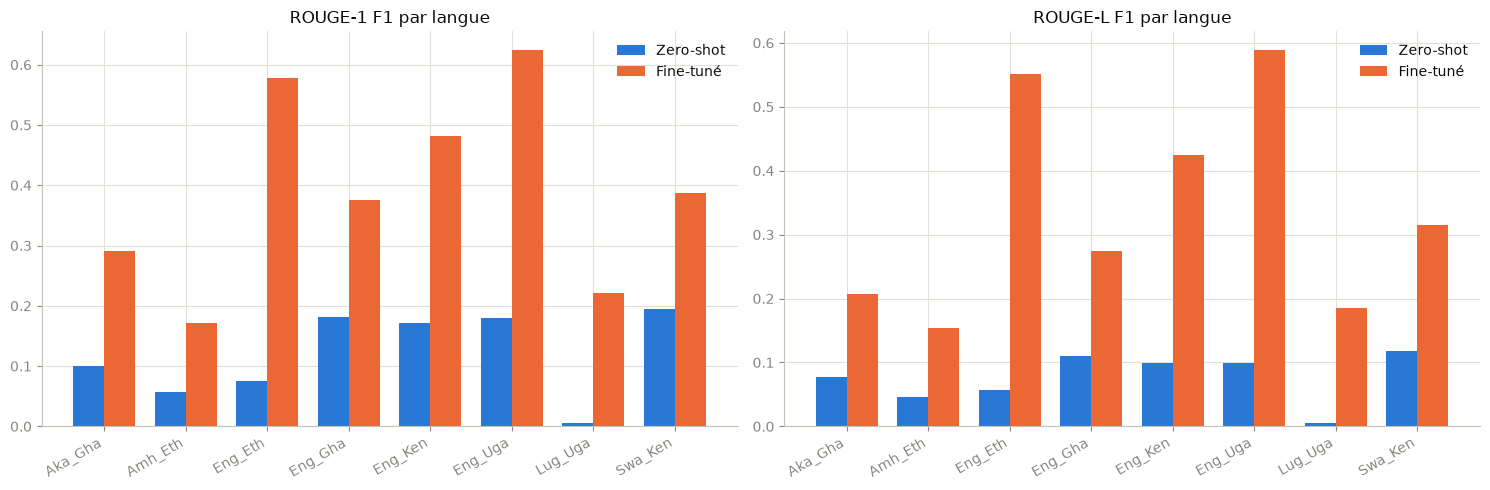

In [19]:
# Compare zero-shot et fine-tuné par langue, pour ROUGE-1 et ROUGE-L.
import matplotlib.pyplot as plt

plt.rcParams.update({  # style commun des graphiques
    'axes.edgecolor': '#c3c2b7',
    'axes.labelcolor': '#52514e',
    'text.color': '#0b0b0b',
    'xtick.color': '#898781',
    'ytick.color': '#898781',
    'axes.grid': True,
    'grid.color': '#e1e0d9',
    'grid.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.axisbelow': True,
})

langs = by_lang.index.tolist()  # langues, dans l'ordre du tableau
x = range(len(langs))
width = 0.38  # largeur d'une barre

fig, axes = plt.subplots(1, 2, figsize=(15, 5))  # un graphique par métrique
for ax, metric, title in [
    (axes[0], 'rouge1', 'ROUGE-1 F1 par langue'),
    (axes[1], 'rougeL', 'ROUGE-L F1 par langue'),
]:
    ax.bar([i - width/2 for i in x], by_lang[f'{metric}_zeroshot'], width, label='Zero-shot', color='#2a78d6')
    ax.bar([i + width/2 for i in x], by_lang[f'{metric}_finetuned'], width, label='Fine-tuné', color='#eb6834')
    ax.set_xticks(list(x))
    ax.set_xticklabels(langs, rotation=30, ha='right')  # codes de langue inclinés
    ax.set_title(title)
    ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [20]:
# Inspection qualitative : 5 exemples côte à côte pour repérer hallucinations, changements de langue ou
# réponses tronquées.
for _, row in val_eval.sample(min(5, len(val_eval)), random_state=SEED).iterrows():  # 5 lignes au hasard
    print(f"[{row['subset']}] {row['input'][:100]}")
    print(f"  Référence  : {row['output'][:200]}")  # réponse attendue (tronquée à 200 caractères)
    print(f"  Zero-shot  : {row['pred_zeroshot'][:200]}")
    print(f"  Fine-tuné  : {row['pred_finetuned'][:200]}")
    print()

[Aka_Gha] Ɔkwan bɛn so na mmabun betumi akamfo wɔn ho ahwɛ ahu sɛ wobenya ayaresa a obu ne animhwɛ nnim afi ak
  Référence  : Ɛsɛ sɛ mmabun di kan kyerɛkyerɛ wɔn ho akwannya ahorow ho asɛm, na wɔkyerɛ hokwan a wɔwɔ sɛ wɔde obu ne animhwɛ nnim di dwuma denam wɔn ahiade ne nea wɔpɛ a wɔbɛka akyerɛ akwahosan ho adwumayɛfo pefee
  Zero-shot  : Voici une réponse en Akan, formulée de manière claire et avec une approche qui vise à être médicalement fiable (tout en rappelant que ce n'est pas un avis médical direct, mais une interprétation cultu
  Fine-tuné  : Mmabun betumi akamfo wɔn ho ahwɛ ahu sɛ wobenya ayaresa a obu ne animhwɛ nnim afi akwaahosan ho adwumayɛfo hɔ denam: Wɔn ankasa gyinapɛn ne wɔn haw ahorow a wɔbɛka akyerɛ wɔn akwahosan ho adwumayɛfo n

[Eng_Gha] Are there specific healthcare providers or clinics that specialize in providing medical assistance t
  Référence  : There are specific healthcare providers or clinics that specialize in providing medical assistance to adolescents 

In [21]:
# (Optionnel) Approximation locale de TargetLLM avec un LLM juge : nécessite une clé API, non configurée
# ici. Squelette à adapter : noter chaque réponse de 1 à 5 (fidélité médicale, fluidité) puis moyenner par
# langue. La soumission Zindi calcule TargetLLM elle-même.
# Exemple de squelette (à activer et adapter si vous avez une clé API) :
#
# JUDGE_PROMPT = (
#     "Question de santé : {question}\n"
#     "Réponse de référence : {reference}\n"
#     "Réponse générée : {generated}\n\n"
#     "Note la réponse générée de 1 (mauvaise) à 5 (excellente) sur la fidélité médicale "
#     "et la fluidité par rapport à la référence. Réponds uniquement avec le chiffre."
# )
#
# def judge_score(question, reference, generated):
#     prompt = JUDGE_PROMPT.format(question=question, reference=reference, generated=generated)
#     # response = client.messages.create(...)  # appel à votre SDK LLM ici
#     # return int(response...)
#     raise NotImplementedError
print('Section optionnelle — non exécutée sans clé API configurée.')

Section optionnelle — non exécutée sans clé API configurée.


In [22]:
# Sauvegarde les résultats (détail, ROUGE par langue, résumé) en CSV sur Drive.
# RESULTS_DIR déjà créé plus haut, avec GEN_CHECKPOINTS_DIR.

# détail : une ligne par exemple, avec prédictions et scores
val_eval.to_csv(f'{RESULTS_DIR}/val_eval_detailed.csv', index=False)
by_lang.to_csv(f'{RESULTS_DIR}/rouge_by_language.csv')  # scores moyens par langue
summary.to_csv(f'{RESULTS_DIR}/rouge_summary.csv', index=False)  # scores globaux

print('Résultats sauvegardés dans', RESULTS_DIR)
print(os.listdir(RESULTS_DIR))

Résultats sauvegardés dans /content/drive/MyDrive/gemmafro-e2b/eval_results
['val_eval_detailed.csv', 'rouge_by_language.csv', 'rouge_summary.csv', 'val_eval_detailed.gsheet', 'checkpoints_generation']


---
**Étape suivante : Phase 5 — analyse d'erreurs et itération**, puis **Phase 6 — génération de la soumission finale** sur `Test.csv` avec `pred_finetuned`.